>>> Wczytano wektor kwantowy (KNN Cosine) o kształcie (563, 15)

>>> Start optymalizacji Walk-Forward (KNN Cosine)...

--- WYNIKI KNN (COSINE) OOS ---
Accuracy: 0.5029 (Thresh = 0.50)
AUC ROC:  0.5050


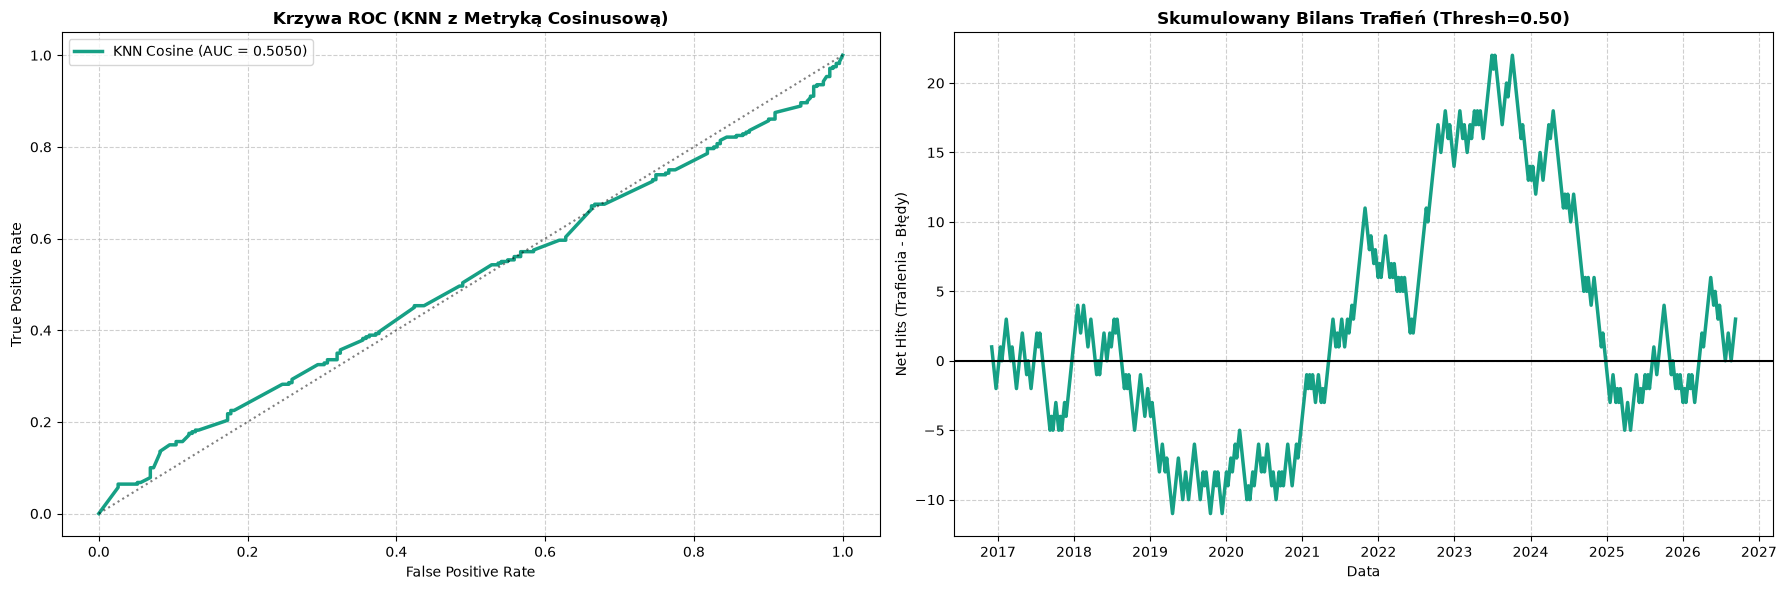

In [1]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA DANYCH
# ==========================================
PLIK_KACHE = "phi_odra_Top5_Rank1_Opt_q1_0.86_1.00_0.80_0.27_0.95.npz" 
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
y = y_raw[LOOKBACK:]
dates = dates_raw[LOOKBACK:]

loaded_archive = np.load(PLIK_KACHE, allow_pickle=True)
first_key = loaded_archive.files[0]
Phi_real = loaded_archive[first_key]

print(f">>> Wczytano wektor kwantowy (KNN Cosine) o kształcie {Phi_real.shape}")

# ==========================================
# 2. TRENOWANIE KROCZĄCE: KNN (Metryka Cosinusowa)
# ==========================================
print("\n>>> Start optymalizacji Walk-Forward (KNN Cosine)...")

TRAIN_WINDOW = 52
inner_cv = TimeSeriesSplit(n_splits=3)

# Brak StandardScalera! Przy metryce cosinusowej zmieniamy wektory, 
# a chcemy zachować surowe kąty z QPU.
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"]
}

results = {"y_true": [], "dates": [], "prob": []}

for t in range(TRAIN_WINDOW, len(y)):
    X_tr, X_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # Inicjalizacja KNN z sztywną metryką cosinusową
    knn = KNeighborsClassifier(metric='cosine')
    
    search = GridSearchCV(knn, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)
    search.fit(X_tr, y_tr)
    
    results["prob"].append(search.predict_proba(X_te)[0, 1])

y_true = np.array(results["y_true"])
prob_preds = np.array(results["prob"])

# SZTYWNY PRÓG 0.50 
final_preds = (prob_preds > 0.50).astype(int)
acc = accuracy_score(y_true, final_preds)
auc = roc_auc_score(y_true, prob_preds)

# ==========================================
# 3. WYNIKI I WIZUALIZACJA
# ==========================================
print(f"\n--- WYNIKI KNN (COSINE) OOS ---")
print(f"Accuracy: {acc:.4f} (Thresh = 0.50)")
print(f"AUC ROC:  {auc:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

fpr, tpr, _ = roc_curve(y_true, prob_preds)
ax[0].plot(fpr, tpr, color='#16a085', lw=2.5, label=f'KNN Cosine (AUC = {auc:.4f})')
ax[0].plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax[0].set_title('Krzywa ROC (KNN z Metryką Cosinusową)', fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

net_hits = np.cumsum(np.where(final_preds == y_true, 1, -1))
ax[1].plot(results["dates"], net_hits, color='#16a085', lw=2.5)
ax[1].axhline(0, color='black', lw=1.5)
ax[1].set_title('Skumulowany Bilans Trafień (Thresh=0.50)', fontweight='bold')
ax[1].set_xlabel('Data')
ax[1].set_ylabel('Net Hits (Trafienia - Błędy)')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()